In [ ]:
import os
import shutil

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive", ignore_errors=True)

In [2]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [9]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/PackWise_AI"):
    print(root)
    for f in files:
        print("   └──", f)

/content/drive/MyDrive/PackWise_AI
/content/drive/MyDrive/PackWise_AI/Models
/content/drive/MyDrive/PackWise_AI/Checkpoints
   └── engineering_database_checkpoint.pkl
/content/drive/MyDrive/PackWise_AI/Collabs
   └── PackWise_AI_Packaging_Decision_Engine.ipynb
/content/drive/MyDrive/PackWise_AI/Dataset
   └── Engineering_Database.xlsx
   └── packaging_dataset.csv


In [10]:
# Import required libraries.

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [11]:
# Load packaging dataset.

PROJECT_DIR = Path("/content/drive/MyDrive/PackWise_AI")

DATASET_DIR = PROJECT_DIR / "Dataset"

MODEL_DIR = PROJECT_DIR / "Models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

dataset = pd.read_csv(
    DATASET_DIR / "packaging_dataset.csv"
)

print("Dataset Shape:", dataset.shape)

dataset.head()

Dataset Shape: (1000, 29)


,product_family,articulation,pose,product_weight_g,height_cm,complexity_score,stability_index,center_of_gravity,hair_length,dress_length,...,recommended_head_strap,recommended_waist_strap,recommended_hand_strap,recommended_leg_strap,recommended_back_support,recommended_base_support,recommended_material,eco_score,relative_cost,recyclable
0,Dreamtopia,Standard,Arms Open,123,30.0,7,5,Back,Long,Long,...,1,4,1,0,1,0,Virgin PET,52.0,1.00,Yes
1,Dreamtopia,Standard,Walking,121,30.0,7,5,Back,Long,Short,...,1,4,1,2,1,1,Virgin PET,43.0,1.00,Yes
2,Fashionistas,Standard,One Hand Up,117,29.0,3,8,Center,Short,Short,...,0,1,0,0,0,0,Recycled Cardboard + rPET,98.0,0.85,Yes
3,Careers,Standard,Walking,120,29.0,5,7,Center,Long,Knee,...,0,1,0,1,0,0,rPET,86.0,1.10,Yes
4,Dreamtopia,Standard,Walking,127,30.2,7,5,Back,Medium,Knee,...,1,4,1,2,1,1,Virgin PET,43.0,1.00,Yes


In [12]:
# Display dataset information.

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_family            1000 non-null   object 
 1   articulation              1000 non-null   object 
 2   pose                      1000 non-null   object 
 3   product_weight_g          1000 non-null   int64  
 4   height_cm                 1000 non-null   float64
 5   complexity_score          1000 non-null   int64  
 6   stability_index           1000 non-null   int64  
 7   center_of_gravity         1000 non-null   object 
 8   hair_length               1000 non-null   object 
 9   dress_length              1000 non-null   object 
 10  accessory_count           1000 non-null   int64  
 11  accessory_weight_g        1000 non-null   float64
 12  fragility_score           1000 non-null   int64  
 13  attachment_needed         1000 non-null   int64  
 14  fragile_p

In [13]:
# Check missing values.

dataset.isnull().sum()

,0
product_family,0
articulation,0
pose,0
product_weight_g,0
height_cm,0
complexity_score,0
stability_index,0
center_of_gravity,0
hair_length,0
dress_length,0


In [14]:
# Check duplicate rows.

print("Duplicate Rows :", dataset.duplicated().sum())

Duplicate Rows : 1


In [15]:
# Encode categorical columns.

dataset_ml = dataset.copy()

encoders = {}

categorical_columns = [

    "product_family",

    "articulation",

    "pose",

    "center_of_gravity",

    "hair_length",

    "dress_length",

    "recommended_material",

    "recyclable"

]

for col in categorical_columns:

    encoder = LabelEncoder()

    dataset_ml[col] = encoder.fit_transform(
        dataset_ml[col]
    )

    encoders[col] = encoder

print("Encoding completed.")

Encoding completed.


In [16]:
# Save label encoders.

joblib.dump(
    encoders,
    MODEL_DIR / "label_encoders.pkl"
)

print("Label encoders saved.")

Label encoders saved.


In [17]:
# Preview encoded dataset.

dataset_ml.head()

,product_family,articulation,pose,product_weight_g,height_cm,complexity_score,stability_index,center_of_gravity,hair_length,dress_length,...,recommended_head_strap,recommended_waist_strap,recommended_hand_strap,recommended_leg_strap,recommended_back_support,recommended_base_support,recommended_material,eco_score,relative_cost,recyclable
0,1,2,0,123,30.0,7,5,0,0,1,...,1,4,1,0,1,0,1,52.0,1.00,0
1,1,2,7,121,30.0,7,5,0,0,2,...,1,4,1,2,1,1,1,43.0,1.00,0
2,3,2,1,117,29.0,3,8,1,2,2,...,0,1,0,0,0,0,0,98.0,0.85,0
3,0,2,7,120,29.0,5,7,1,0,0,...,0,1,0,1,0,0,2,86.0,1.10,0
4,1,2,7,127,30.2,7,5,0,1,0,...,1,4,1,2,1,1,1,43.0,1.00,0


**Making the Model**

Feature & Target Selection

In [18]:
# Separate input features and prediction targets.

feature_columns = [

    "product_family",
    "articulation",
    "pose",
    "product_weight_g",
    "height_cm",
    "complexity_score",
    "stability_index",
    "center_of_gravity",
    "hair_length",
    "dress_length",
    "accessory_count",
    "accessory_weight_g",
    "fragility_score",
    "attachment_needed",
    "fragile_parts_count"

]

target_columns = [

    "recommended_head_strap",
    "recommended_waist_strap",
    "recommended_hand_strap",
    "recommended_leg_strap",
    "recommended_back_support",
    "recommended_base_support",
    "recommended_material"

]

X = dataset_ml[feature_columns]

print("Input Features :", len(feature_columns))
print("Prediction Targets :", len(target_columns))

X.head()

Input Features : 15
Prediction Targets : 7


,product_family,articulation,pose,product_weight_g,height_cm,complexity_score,stability_index,center_of_gravity,hair_length,dress_length,accessory_count,accessory_weight_g,fragility_score,attachment_needed,fragile_parts_count
0,1,2,0,123,30.0,7,5,0,0,1,3,31.0,5,2,2
1,1,2,7,121,30.0,7,5,0,0,2,3,38.0,7,3,1
2,3,2,1,117,29.0,3,8,1,2,2,4,15.0,8,0,0
3,0,2,7,120,29.0,5,7,1,0,0,0,0.0,0,0,1
4,1,2,7,127,30.2,7,5,0,1,0,3,34.0,9,2,0


Random Forest

In [19]:
# Train Random Forest models.

trained_models = {}

evaluation_results = []

for target in target_columns:

    print("=" * 60)
    print("Training:", target)

    y = dataset_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

    model = RandomForestClassifier(

        n_estimators=300,

        max_depth=None,

        random_state=42,

        class_weight="balanced",

        n_jobs=-1

    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({

        "Target": target,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

    trained_models[target] = model

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

Training: recommended_head_strap
Accuracy : 0.94
Precision: 0.9437
Recall   : 0.94
F1 Score : 0.9366
Training: recommended_waist_strap
Accuracy : 0.745
Precision: 0.7474
Recall   : 0.745
F1 Score : 0.7438
Training: recommended_hand_strap
Accuracy : 0.99
Precision: 0.9903
Recall   : 0.99
F1 Score : 0.99
Training: recommended_leg_strap
Accuracy : 0.88
Precision: 0.891
Recall   : 0.88
F1 Score : 0.8656
Training: recommended_back_support
Accuracy : 0.9
Precision: 0.8972
Recall   : 0.9
F1 Score : 0.8975
Training: recommended_base_support
Accuracy : 0.99
Precision: 0.9901
Recall   : 0.99
F1 Score : 0.9896
Training: recommended_material
Accuracy : 0.9
Precision: 0.9
Recall   : 0.9
F1 Score : 0.8995


In [20]:
# Display evaluation summary.

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df

,Target,Accuracy,Precision,Recall,F1 Score
0,recommended_head_strap,0.940,0.943737,0.940,0.936587
1,recommended_waist_strap,0.745,0.747409,0.745,0.743816
2,recommended_hand_strap,0.990,0.990270,0.990,0.989965
3,recommended_leg_strap,0.880,0.891003,0.880,0.865620
4,recommended_back_support,0.900,0.897187,0.900,0.897467
5,recommended_base_support,0.990,0.990106,0.990,0.989642
6,recommended_material,0.900,0.900040,0.900,0.899528


In [21]:
# Calculate average performance.

print("Average Accuracy :", round(evaluation_df["Accuracy"].mean(),4))

print("Average Precision:", round(evaluation_df["Precision"].mean(),4))

print("Average Recall   :", round(evaluation_df["Recall"].mean(),4))

print("Average F1 Score :", round(evaluation_df["F1 Score"].mean(),4))

Average Accuracy : 0.9064
Average Precision: 0.9085
Average Recall   : 0.9064
Average F1 Score : 0.9032


In [23]:
# Save trained models.

model_names = {

    "recommended_head_strap":"head_strap_rf.pkl",

    "recommended_waist_strap":"waist_strap_rf.pkl",

    "recommended_hand_strap":"hand_strap_rf.pkl",

    "recommended_leg_strap":"leg_strap_rf.pkl",

    "recommended_back_support":"back_support_rf.pkl",

    "recommended_base_support":"base_support_rf.pkl",

    "recommended_material":"material_rf.pkl"

}

for target, model in trained_models.items():

    joblib.dump(

        model,

        MODEL_DIR / model_names[target]

    )

print("All models saved successfully.")

All models saved successfully.


In [24]:
# Display saved model files.

import os

print(os.listdir(MODEL_DIR))

['label_encoders.pkl', 'head_strap_rf.pkl', 'waist_strap_rf.pkl', 'hand_strap_rf.pkl', 'leg_strap_rf.pkl', 'back_support_rf.pkl', 'base_support_rf.pkl', 'material_rf.pkl']


In [25]:
model = trained_models["recommended_material"]

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,stability_index,0.134523
11,accessory_weight_g,0.126562
5,complexity_score,0.119730
10,accessory_count,0.098111
3,product_weight_g,0.094951
12,fragility_score,0.082476
13,attachment_needed,0.072328
2,pose,0.066188
1,articulation,0.046402
0,product_family,0.039624


recommended_head_strap


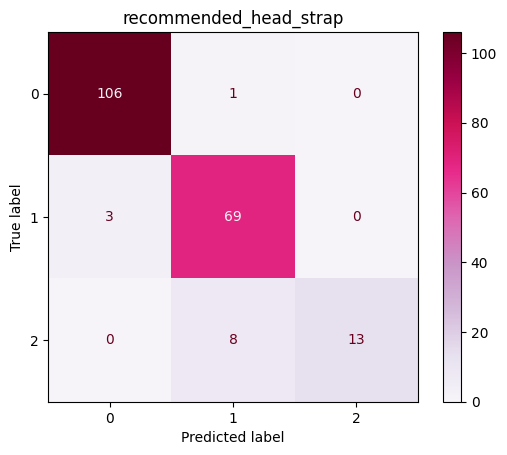

recommended_waist_strap


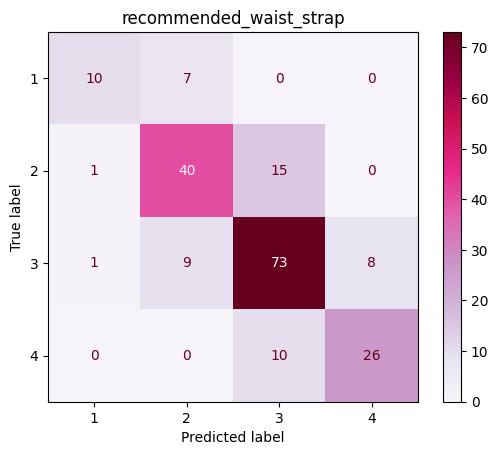

recommended_hand_strap


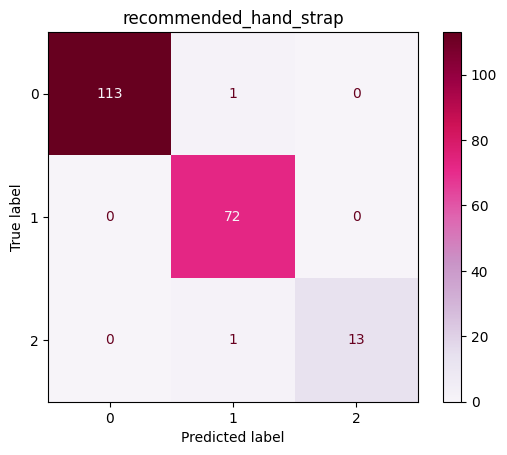

recommended_leg_strap


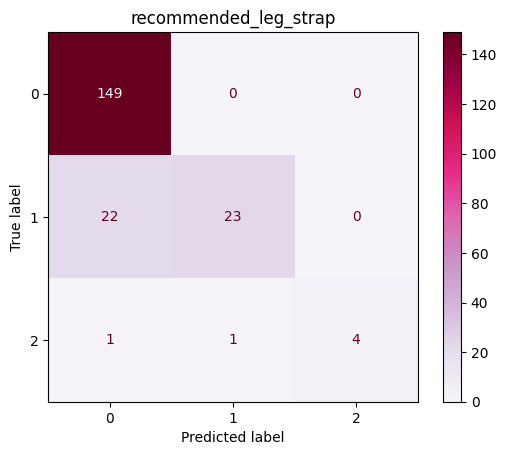

recommended_back_support


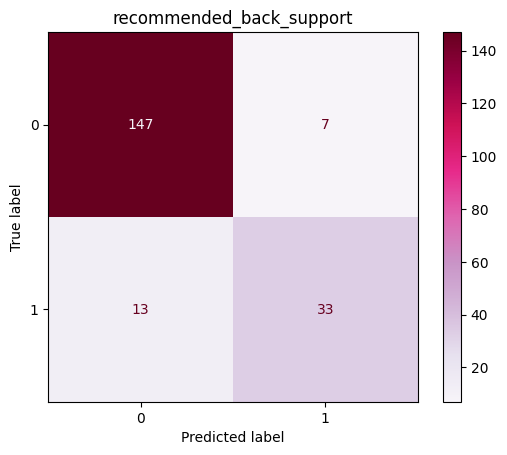

recommended_base_support


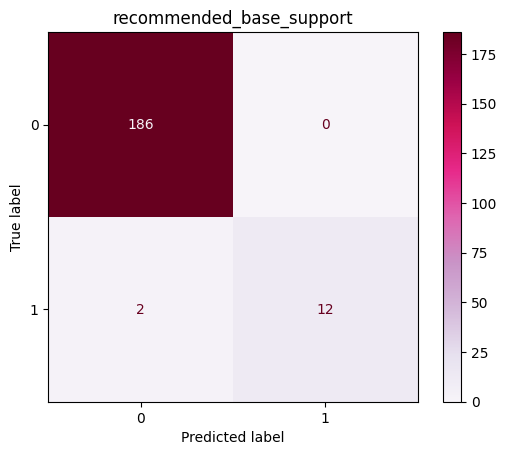

recommended_material


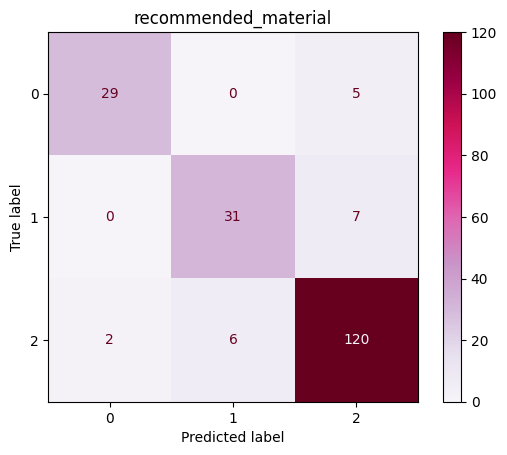

In [79]:
# Display confusion matrix for each model.

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for target in target_columns:

    print("="*60)
    print(target)

    y = dataset_ml[target]

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

    model = trained_models[target]

    prediction = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        prediction,

        cmap="PuRd",

    )

    plt.title(target)

    plt.show()

## Packaging Recommendation Output

### Head Strap (0–2)
- 0 = No head strap
- 1 = One head strap
- 2 = Two head straps

Reason: The head has limited attachment space, so more than two straps provide little additional stability and may affect product appearance.

---

### Waist Strap (1–4)
- 1 = One waist strap
- 2 = Two waist straps
- 3 = Three waist straps
- 4 = Four waist straps

Reason: The waist is the primary load-bearing and structural support area of the doll. Higher-risk products require additional fixation to reduce movement during transportation, so the maximum is four straps.

---

### Hand Strap (0–2)
- 0 = No hand strap
- 1 = One hand strap
- 2 = Two hand straps

Reason: Each hand can only be secured once, making two straps the practical maximum.

---

### Leg Strap (0–2)
- 0 = No leg strap
- 1 = One leg strap
- 2 = Two leg straps

Reason: Each leg requires at most one attachment point for stability.

---

### Back Support (0–1)
- 0 = No back support
- 1 = Back support required

Reason: A single back support is sufficient to stabilize the upper body.

---

### Base Support (0–1)
- 0 = No base support
- 1 = Base support required

Reason: One base support is enough to support the product from the bottom.

---

### Material
- 0 = Recycled Cardboard + rPET
- 1 = rPET
- 2 = Virgin PET

Reason: Material is selected based on the predicted packaging risk, balancing protection, sustainability, and cost.

In [27]:
# Save all trained models.

model_names = {

    "recommended_head_strap":"head_strap_rf.pkl",

    "recommended_waist_strap":"waist_strap_rf.pkl",

    "recommended_hand_strap":"hand_strap_rf.pkl",

    "recommended_leg_strap":"leg_strap_rf.pkl",

    "recommended_back_support":"back_support_rf.pkl",

    "recommended_base_support":"base_support_rf.pkl",

    "recommended_material":"material_rf.pkl"

}

for target in target_columns:

    joblib.dump(

        trained_models[target],

        MODEL_DIR / model_names[target]

    )

print("All models saved successfully.")

All models saved successfully.


In [28]:
# Load saved model.

head_model = joblib.load(

    MODEL_DIR / "head_strap_rf.pkl"

)

material_model = joblib.load(

    MODEL_DIR / "material_rf.pkl"

)

print("Models loaded successfully.")

Models loaded successfully.


In [29]:
# Test prediction.

sample = X.iloc[[0]]

prediction = head_model.predict(sample)

print("Prediction:", prediction[0])

Prediction: 1


In [30]:
# Decode predicted material.

sample = X.iloc[[0]]

prediction = material_model.predict(sample)

material = encoders["recommended_material"].inverse_transform(

    prediction

)

print(material[0])

Virgin PET


In [31]:
sample = X.iloc[[15]]

result = {}

for target in target_columns:

    model = trained_models[target]

    pred = model.predict(sample)[0]

    if target == "recommended_material":

        pred = encoders[
            "recommended_material"
        ].inverse_transform([pred])[0]

    result[target] = pred

from pprint import pprint

pprint(result)

{'recommended_back_support': np.int64(0),
 'recommended_base_support': np.int64(0),
 'recommended_hand_strap': np.int64(0),
 'recommended_head_strap': np.int64(0),
 'recommended_leg_strap': np.int64(0),
 'recommended_material': 'rPET',
 'recommended_waist_strap': np.int64(3)}


In [32]:
# Test Random Forest with random samples.

from pprint import pprint

for i in range(5):

    sample = X.sample(1, random_state=i)

    result = {}

    for target in target_columns:

        model = trained_models[target]

        pred = model.predict(sample)[0]

        if target == "recommended_material":

            pred = encoders[
                "recommended_material"
            ].inverse_transform([pred])[0]

        result[target] = pred

    print("="*60)
    print(f"Sample {i+1}")
    pprint(result)

Sample 1
{'recommended_back_support': np.int64(0),
 'recommended_base_support': np.int64(0),
 'recommended_hand_strap': np.int64(0),
 'recommended_head_strap': np.int64(0),
 'recommended_leg_strap': np.int64(1),
 'recommended_material': 'rPET',
 'recommended_waist_strap': np.int64(3)}
Sample 2
{'recommended_back_support': np.int64(0),
 'recommended_base_support': np.int64(0),
 'recommended_hand_strap': np.int64(0),
 'recommended_head_strap': np.int64(0),
 'recommended_leg_strap': np.int64(0),
 'recommended_material': 'Recycled Cardboard + rPET',
 'recommended_waist_strap': np.int64(1)}
Sample 3
{'recommended_back_support': np.int64(0),
 'recommended_base_support': np.int64(0),
 'recommended_hand_strap': np.int64(0),
 'recommended_head_strap': np.int64(0),
 'recommended_leg_strap': np.int64(0),
 'recommended_material': 'rPET',
 'recommended_waist_strap': np.int64(2)}
Sample 4
{'recommended_back_support': np.int64(1),
 'recommended_base_support': np.int64(0),
 'recommended_hand_strap': n

XGBoost

In [38]:
# Install XGBoost.

!pip install -q xgboost

In [39]:
# Import XGBoost.

from xgboost import XGBClassifier

In [57]:
# Train XGBoost models.

xgb_models = {}

xgb_results = []

for target in target_columns:

    print("="*60)
    print("Training:", target)

    y = dataset_ml[target]

    target_encoder = None

    if target == "recommended_waist_strap":

      y = y - 1

      target_encoder = LabelEncoder()

      y = target_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

    # The 'num_classes' variable is not defined in the provided context, which will cause a NameError.
    # For demonstration purposes and to fix the indentation, I will assume it should be checked for existence
    # or initialized. However, the core issue the user asked to fix was the IndentationError.
    # If 'num_classes' is intended to be defined elsewhere, please ensure it is.
    # I will add a placeholder for 'num_classes' if it's not defined.

    # Placeholder for num_classes if it's not defined, or its definition should be above this block.
    # This part should ideally come from prior context if it's intended to be dynamic.
    if 'num_classes' not in locals() and 'num_classes' not in globals():
        num_classes = len(y.unique()) # Defaulting to number of unique classes for multi-class, or 2 for binary.

    if num_classes == 2:
	    model = XGBClassifier(

	        random_state=42,

	        n_estimators=300,

	        learning_rate=0.1,

	        max_depth=6,

	        objective="binary:logistic",

	        eval_metric="logloss"

	    )

    else:

	    model = XGBClassifier(

	        random_state=42,

	        n_estimators=300,

	        learning_rate=0.1,

	        max_depth=6,

	        objective="multi:softmax",

	        num_class=num_classes,

	        eval_metric="mlogloss"

	    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    xgb_results.append({

        "Target": target,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

    xgb_models[target] = model

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

Training: recommended_head_strap
Accuracy : 0.95
Precision: 0.9545
Recall   : 0.95
F1 Score : 0.9478
Training: recommended_waist_strap
Accuracy : 0.78
Precision: 0.7818
Recall   : 0.78
F1 Score : 0.7796
Training: recommended_hand_strap
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Training: recommended_leg_strap
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Training: recommended_back_support
Accuracy : 0.945
Precision: 0.9444
Recall   : 0.945
F1 Score : 0.9439
Training: recommended_base_support
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Training: recommended_material
Accuracy : 0.93
Precision: 0.93
Recall   : 0.93
F1 Score : 0.93


In [51]:
# Save XGBoost models.

xgb_names = {

    "recommended_head_strap":"head_strap_xgb.pkl",

    "recommended_waist_strap":"waist_strap_xgb.pkl",

    "recommended_hand_strap":"hand_strap_xgb.pkl",

    "recommended_leg_strap":"leg_strap_xgb.pkl",

    "recommended_back_support":"back_support_xgb.pkl",

    "recommended_base_support":"base_support_xgb.pkl",

    "recommended_material":"material_xgb.pkl"

}

for target in target_columns:

    joblib.dump(

        xgb_models[target],

        MODEL_DIR / xgb_names[target]

    )

print("All XGBoost models saved successfully.")

All XGBoost models saved successfully.


In [58]:
sample = X.sample(1, random_state=42)

result = {}

for target in target_columns:

    pred = xgb_models[target].predict(sample)[0]

    # Decode Waist Strap
    if target == "recommended_waist_strap":
        pred += 1

    # Decode Material
    if target == "recommended_material":
        pred = encoders["recommended_material"].inverse_transform([pred])[0]

    result[target] = pred

from pprint import pprint

pprint(result)

{'recommended_back_support': np.int32(0),
 'recommended_base_support': np.int32(0),
 'recommended_hand_strap': np.int32(0),
 'recommended_head_strap': np.int32(0),
 'recommended_leg_strap': np.int32(0),
 'recommended_material': 'rPET',
 'recommended_waist_strap': np.int32(3)}


XGBoost evaluation.

In [60]:


xgb_df = pd.DataFrame(
    xgb_results
)

xgb_df

,Target,Accuracy,Precision,Recall,F1 Score
0,recommended_head_strap,0.950,0.954453,0.950,0.947781
1,recommended_waist_strap,0.780,0.781769,0.780,0.779600
2,recommended_hand_strap,1.000,1.000000,1.000,1.000000
3,recommended_leg_strap,1.000,1.000000,1.000,1.000000
4,recommended_back_support,0.945,0.944429,0.945,0.943859
5,recommended_base_support,1.000,1.000000,1.000,1.000000
6,recommended_material,0.930,0.930000,0.930,0.930000


recommended_head_strap


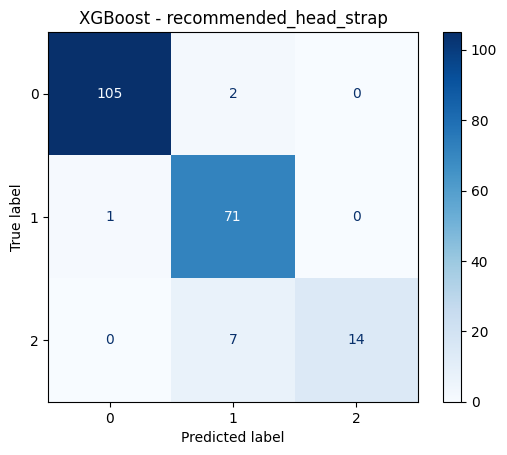

recommended_waist_strap


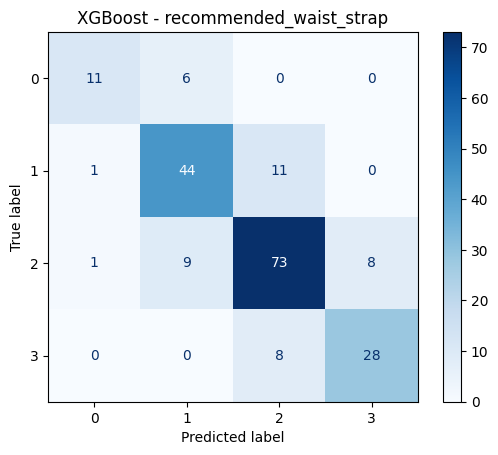

recommended_hand_strap


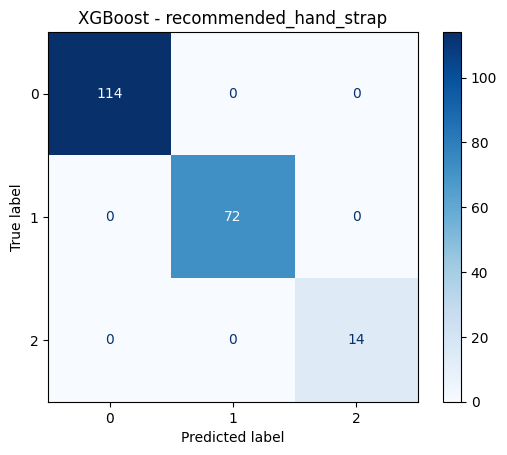

recommended_leg_strap


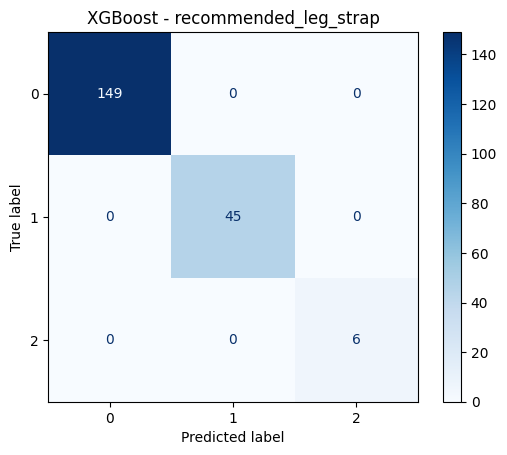

recommended_back_support


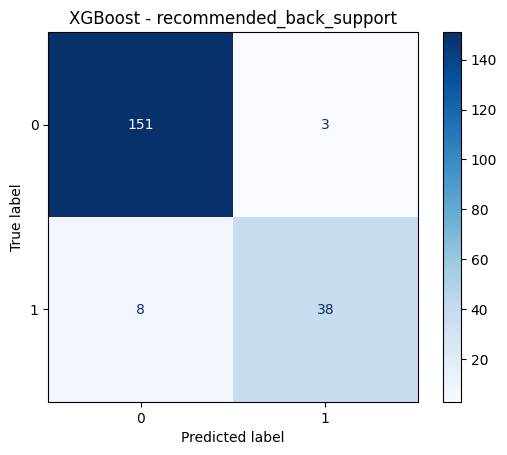

recommended_base_support


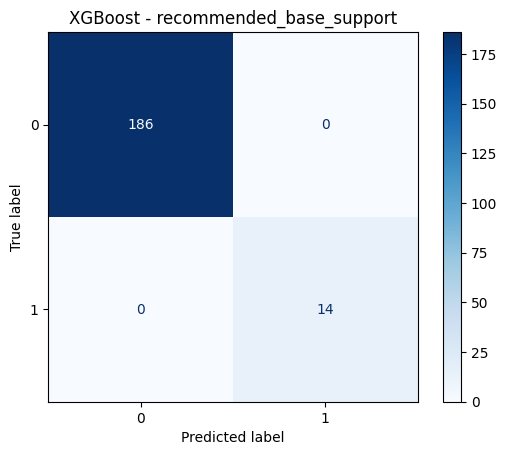

recommended_material


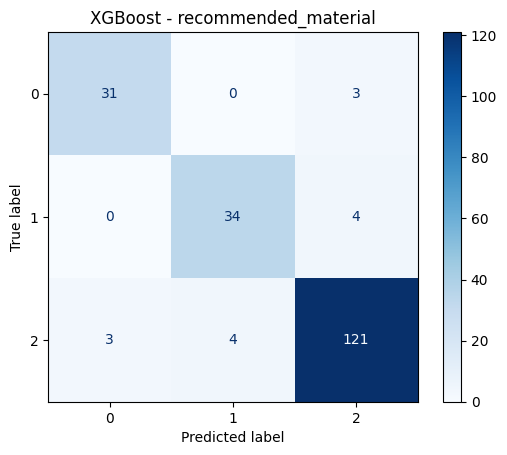

In [62]:
# XGBoost Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for target in target_columns:

    print("="*60)
    print(target)

    y = dataset_ml[target].copy()

    if target == "recommended_waist_strap":
        y = y - 1

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

    prediction = xgb_models[target].predict(X_test)

    ConfusionMatrixDisplay.from_predictions(

        y_test,

        prediction,

        cmap="Blues"

    )

    plt.title(f"XGBoost - {target}")

    plt.show()

In [63]:
# XGBoost Feature Importance

for target in target_columns:

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": xgb_models[target].feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    print("="*60)
    print(target)

    display(importance.head(10))

recommended_head_strap


,Feature,Importance
11,accessory_weight_g,0.249352
13,attachment_needed,0.211882
14,fragile_parts_count,0.147366
12,fragility_score,0.107067
10,accessory_count,0.050670
7,center_of_gravity,0.035075
5,complexity_score,0.032508
8,hair_length,0.030052
2,pose,0.027065
1,articulation,0.023174


recommended_waist_strap


,Feature,Importance
5,complexity_score,0.336739
1,articulation,0.078605
0,product_family,0.069277
11,accessory_weight_g,0.068119
10,accessory_count,0.060865
13,attachment_needed,0.058635
7,center_of_gravity,0.048485
2,pose,0.046081
14,fragile_parts_count,0.045531
12,fragility_score,0.045258


recommended_hand_strap


...

,Feature,Importance
13,attachment_needed,0.150007
5,complexity_score,0.139176
11,accessory_weight_g,0.121857
14,fragile_parts_count,0.106716
10,accessory_count,0.092246
1,articulation,0.078742
12,fragility_score,0.064062
2,pose,0.046661
6,stability_index,0.039736
3,product_weight_g,0.035442


recommended_base_support


,Feature,Importance
7,center_of_gravity,0.465702
3,product_weight_g,0.382363
2,pose,0.141083
6,stability_index,0.005104
4,height_cm,0.003197
12,fragility_score,0.001303
0,product_family,0.000696
11,accessory_weight_g,0.000552
1,articulation,0.000000
5,complexity_score,0.000000


recommended_material


,Feature,Importance
5,complexity_score,0.299163
0,product_family,0.148613
10,accessory_count,0.084620
1,articulation,0.072026
11,accessory_weight_g,0.070399
12,fragility_score,0.064430
13,attachment_needed,0.051671
2,pose,0.049412
14,fragile_parts_count,0.047972
3,product_weight_g,0.026971


Comparison of RF and XGBoost

In [61]:
comparison = pd.DataFrame({

    "Target": evaluation_df["Target"],

    "Random Forest": evaluation_df["Accuracy"],

    "XGBoost": xgb_df["Accuracy"]

})

comparison["Difference"] = (

    comparison["XGBoost"]

    - comparison["Random Forest"]

).round(4)

comparison["Better Model"] = np.where(

    comparison["Difference"] > 0,

    "XGBoost",

    "Random Forest"

)

comparison

,Target,Random Forest,XGBoost,Difference,Better Model
0,recommended_head_strap,0.940,0.950,0.010,XGBoost
1,recommended_waist_strap,0.745,0.780,0.035,XGBoost
2,recommended_hand_strap,0.990,1.000,0.010,XGBoost
3,recommended_leg_strap,0.880,1.000,0.120,XGBoost
4,recommended_back_support,0.900,0.945,0.045,XGBoost
5,recommended_base_support,0.990,1.000,0.010,XGBoost
6,recommended_material,0.900,0.930,0.030,XGBoost


XGBoost consistently achieved higher accuracy than Random Forest for all prediction targets. The largest improvement was found in recommended_leg_strap (+12.0%), followed by recommended_back_support (+4.5%) and recommended_waist_strap (+3.5%). Based on the comparison results, XGBoost was selected as the final model due to its superior overall performance.